# Preprocessing Workflow for reverberation removal

This notebook loads the same DICOM acquisition and hardcoded ROI used in the reverberation report, applies different filters and calculations to remove reverberations.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pydicom
from skimage.morphology import white_tophat
from skimage.filters import frangi, sato, meijering
import napari
from napari.utils import nbscreenshot

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap'] = 'gray'

In [2]:
# Same source and selection as reverberation_artifact_report.ipynb
repository_root = Path('..').resolve()
dicom_input_dir = repository_root / 'data' / 'ultrasound' / 'raices reales' / '1'
dicom_files = sorted(dicom_input_dir.glob('*.dcm'))

if len(dicom_files) == 0:
    raise FileNotFoundError(f'No DICOM files found in: {dicom_input_dir}')

selected_dicom_index = 0
selected_dicom_path = dicom_files[selected_dicom_index]
dataset = pydicom.dcmread(selected_dicom_path)
raw = dataset.pixel_array

if raw.ndim == 4:
    frames = raw[..., 0]
elif raw.ndim == 3:
    frames = raw
elif raw.ndim == 2:
    frames = raw[np.newaxis, ...]
else:
    raise ValueError(f'Unsupported DICOM pixel array shape: {raw.shape}')

# Same hardcoded ROI from the report
min_x, max_x = 401, 619
min_y, max_y = 116, 689

y0 = max(0, min_y)
y1 = min(frames.shape[1] - 1, max_y)
x0 = max(0, min_x)
x1 = min(frames.shape[2] - 1, max_x)

if y0 > y1 or x0 > x1:
    raise ValueError('Invalid ROI after clipping. Check min/max x/y values.')

roi_mask_2d = np.zeros(frames.shape[1:], dtype=bool)
roi_mask_2d[y0:y1 + 1, x0:x1 + 1] = True
volume = frames[:, y0:y1 + 1, x0:x1 + 1].astype(np.float32)

print(f'Loaded DICOM: {selected_dicom_path}')
print(f'frames shape: {frames.shape}, ROI volume shape: {volume.shape}')

Loaded DICOM: C:\Users\corba\Documents\eco-root\data\ultrasound\raices reales\1\001.dcm
frames shape: (189, 768, 1024), ROI volume shape: (189, 574, 219)


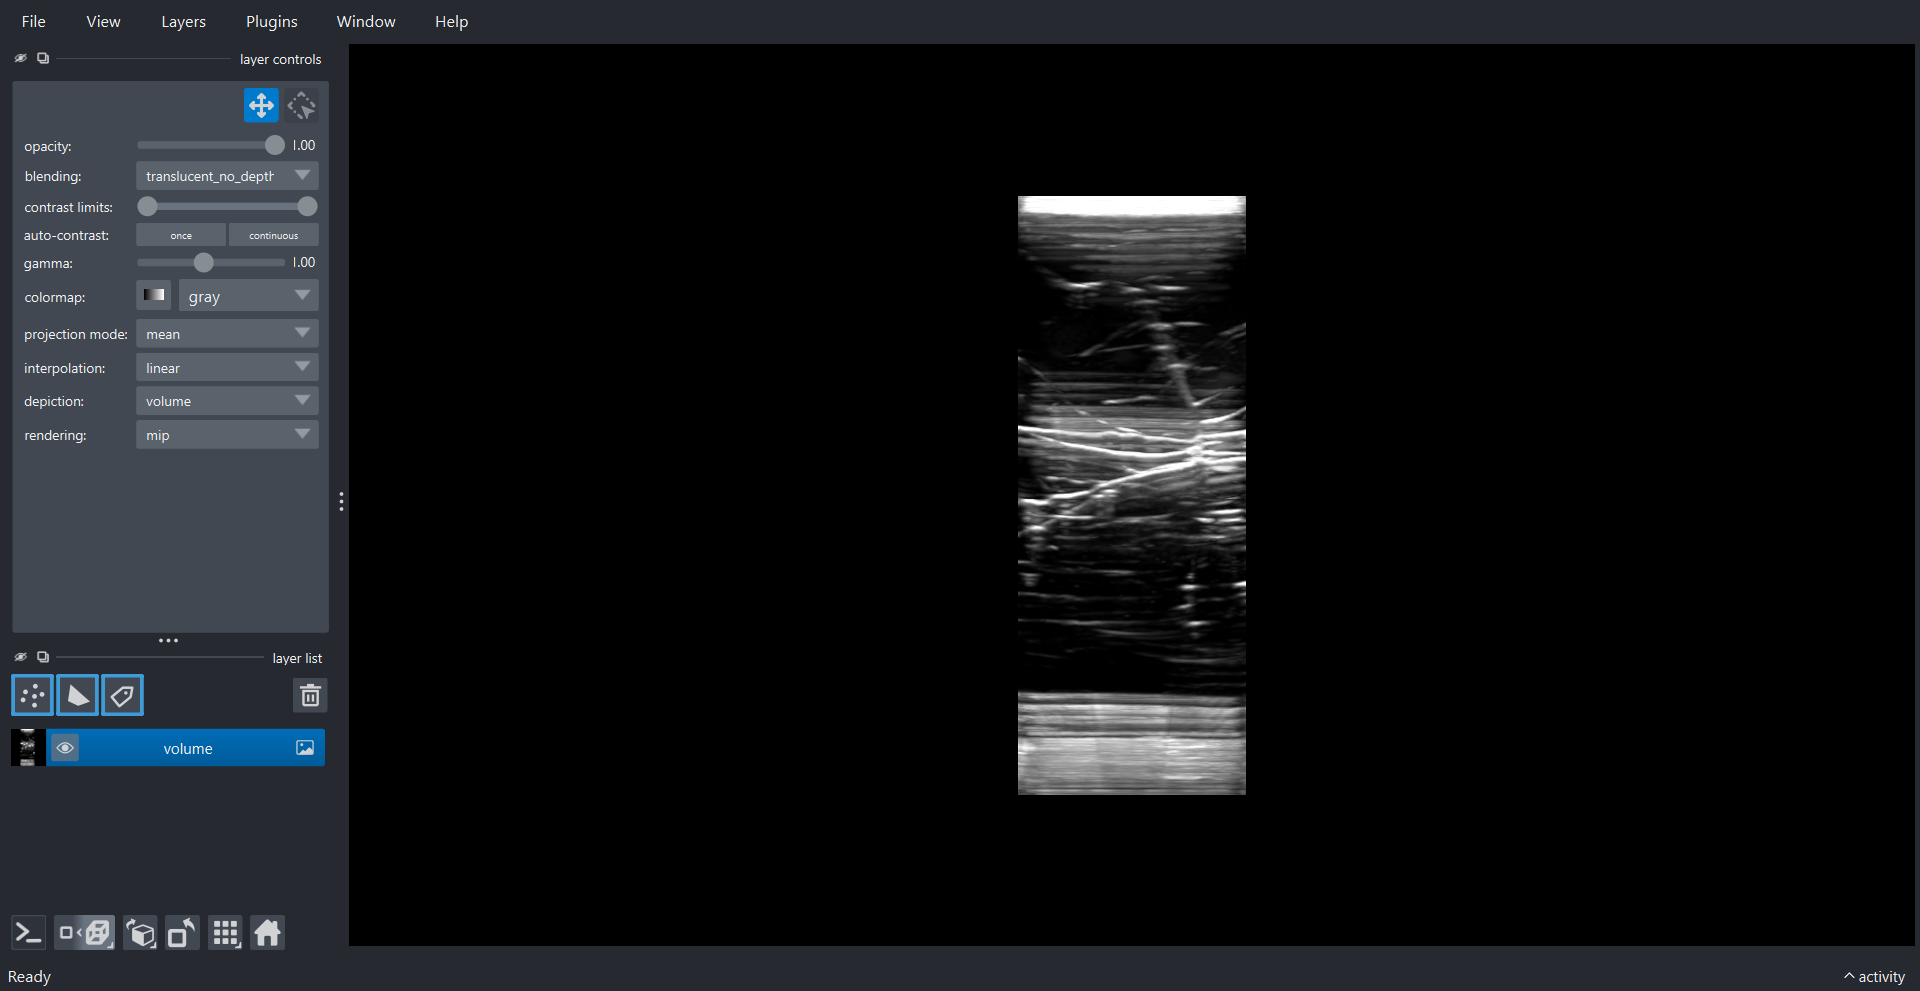

In [3]:
viewer = napari.Viewer(title='Raw Volume', ndisplay=3)
viewer.add_image(volume, name='volume', colormap='gray')

nbscreenshot(viewer)

## 1) Calculate median image in z

If we consider that the reverberances are quite still in every plane, we can first estimate the median image across z. This image can be subtracted from every plane to attempt to get rid of the reverberances.

In [4]:
median_image = np.median(volume, axis=0)
background_subtracted = volume - median_image[...]
background_subtracted = np.clip(background_subtracted, 0, np.inf)

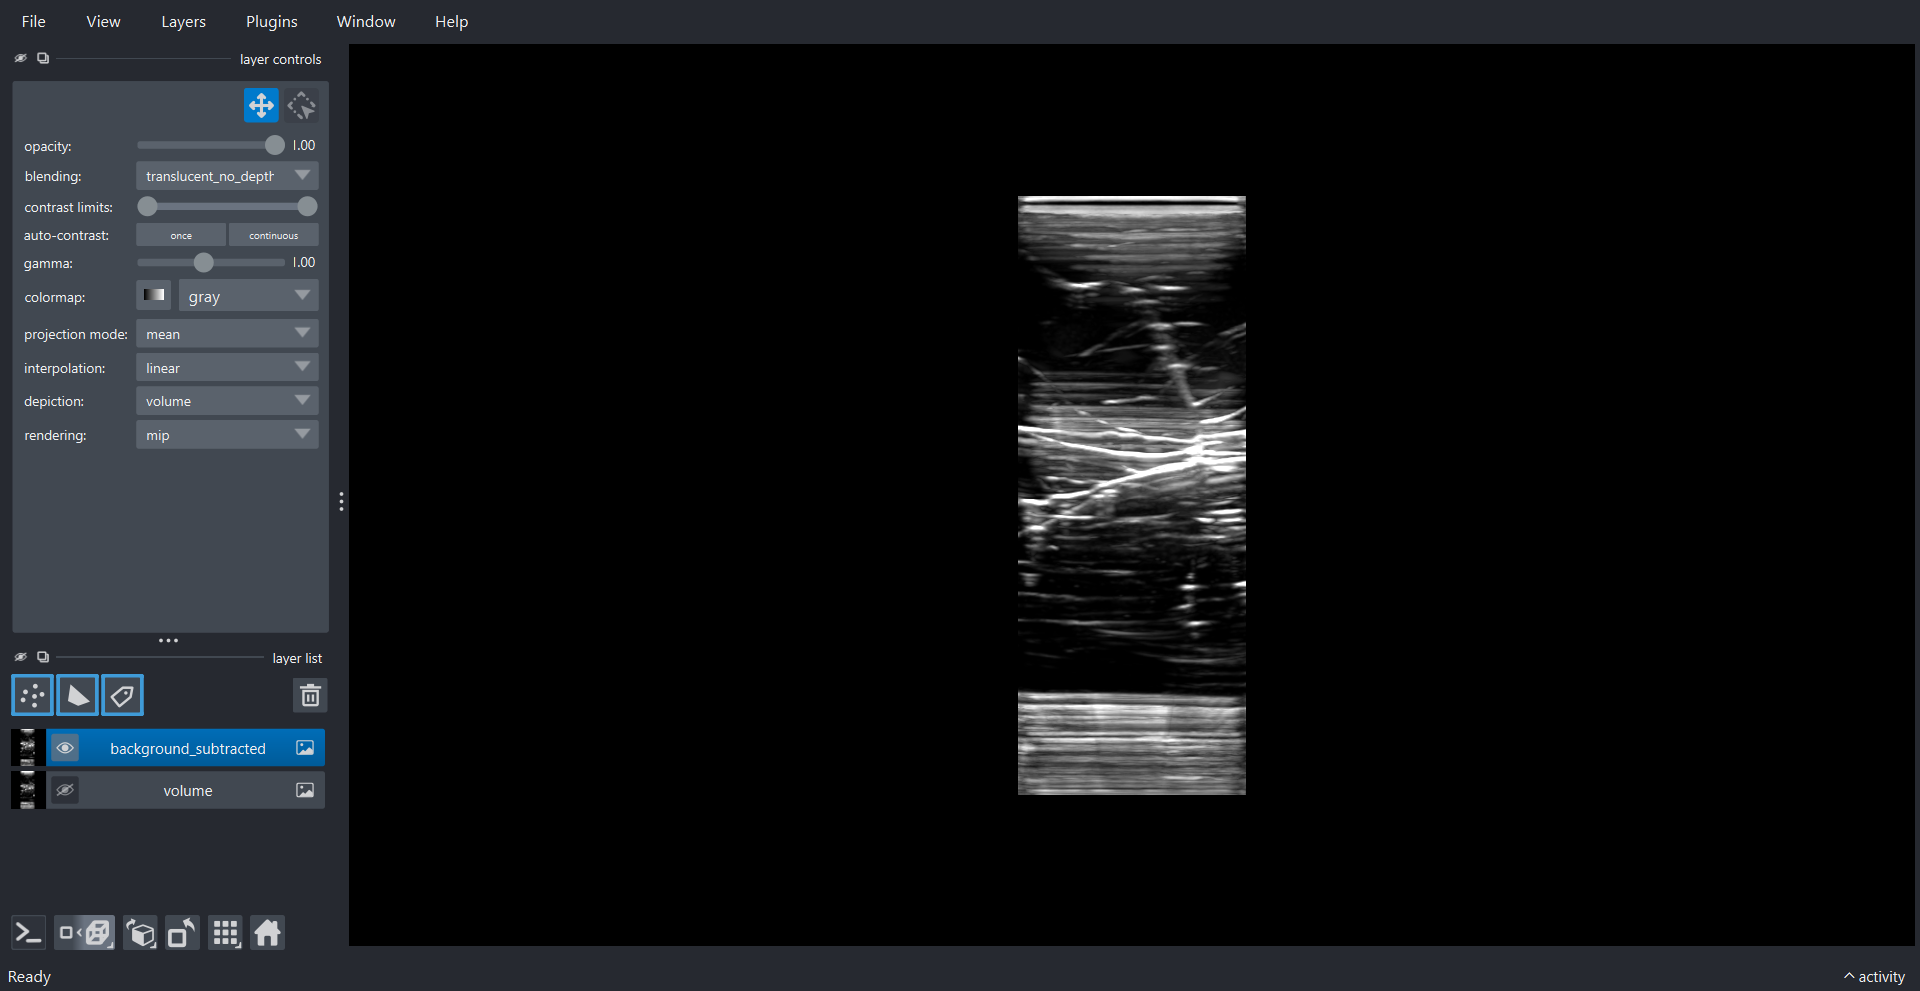

In [5]:
viewer = napari.Viewer(title='Median Subtracted', ndisplay=3)
viewer.add_image(volume, name='volume', colormap='gray').visible = False
viewer.add_image(background_subtracted, name='background_subtracted', colormap='gray')

nbscreenshot(viewer)

## 1) Apply white tophat in plane perpendicular to wave propagation

Perpendicular to wave propagation, the reverberances look quite homogeneous, this translates into a rolling ball or white tophat filter being ideal to remove some of the noise.

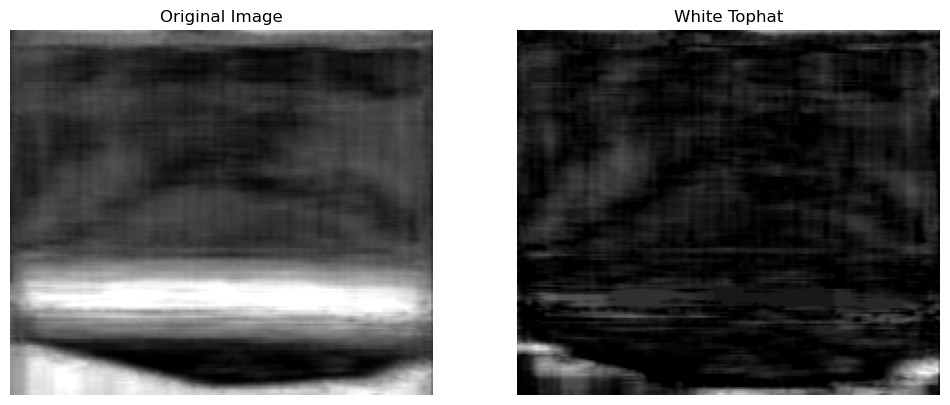

In [6]:
import matplotlib.pyplot as plt

example_image = np.swapaxes(volume, 0, 1)[0]

footprint = np.ones((10, 60), dtype=bool)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(example_image)
axs[0].set_title("Original Image")
axs[0].axis('off')
axs[1].imshow(white_tophat(example_image, footprint))
axs[1].set_title("White Tophat")
axs[1].axis('off')
plt.show()

We will define a function to apply white tophat to every plane in the direction of wave propagation.

In [7]:
def process_white_tophat(volume, footprint = np.ones((20, 20), dtype=bool)):
    processed_volume = np.zeros_like(volume)
    processed_volume = np.swapaxes(processed_volume, 0, 1)
    for n, plane in enumerate(np.swapaxes(volume, 0, 1)):
        processed_volume[n] = white_tophat(plane, footprint)
    
    return np.swapaxes(processed_volume, 0, 1)

In [8]:
white_tophat_processed = process_white_tophat(background_subtracted, footprint = np.ones((10, 60), dtype=bool))

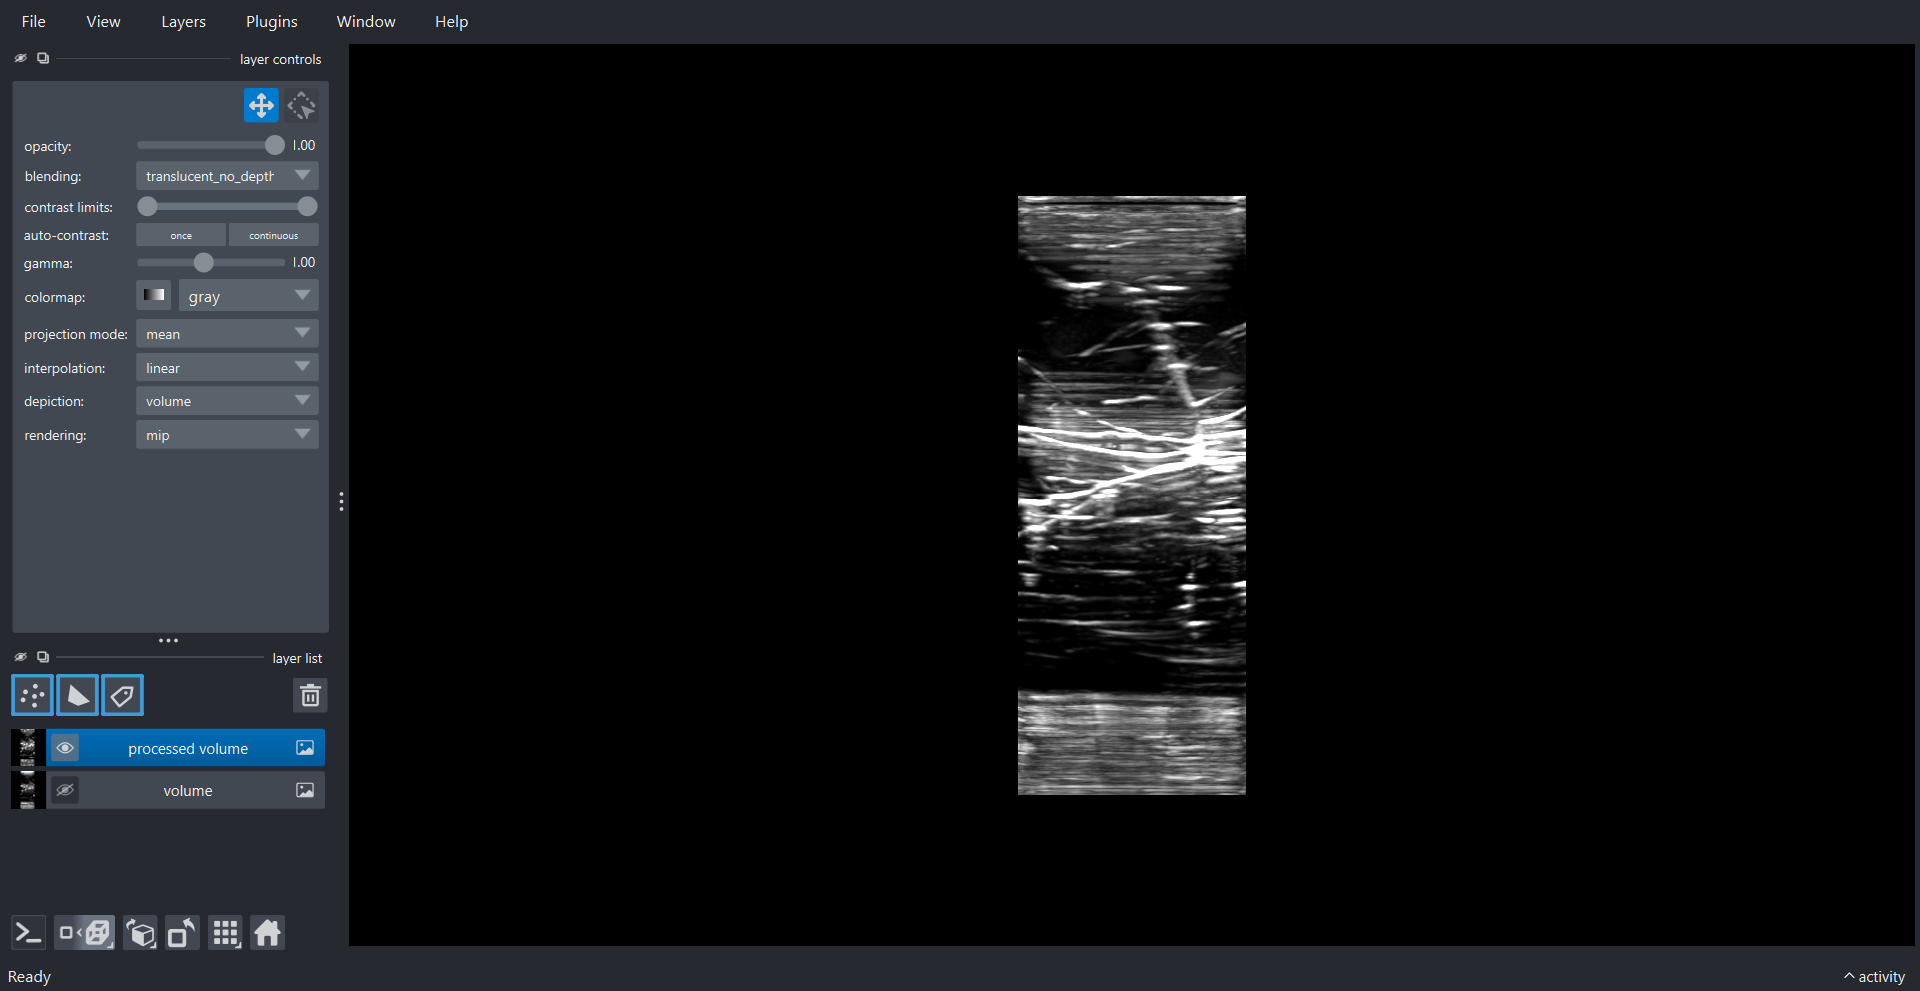

In [9]:
viewer_results = napari.Viewer(title='White Tophat Processing', ndisplay=3)
viewer_results.add_image(volume, name='volume', colormap='gray').visible = False
viewer_results.add_image(white_tophat_processed, name='processed volume', colormap='gray')
nbscreenshot(viewer_results)

# 3) Vesselness filters

We can look into several vesselness filters in 2D and 3D to see how we can highlight even more the roots.

In [10]:
def process_with_meijering(volume, sigmas = (1, 2, 3)):
    processed_volume = np.zeros_like(volume)
    processed_volume = np.swapaxes(processed_volume, 0, 1)
    print(processed_volume.shape)
    for n, plane in enumerate(np.swapaxes(volume, 0, 1)):
        processed_volume[n] = meijering(plane, black_ridges=False, sigmas=sigmas)

    return np.swapaxes(processed_volume, 0, 1)

(574, 189, 219)


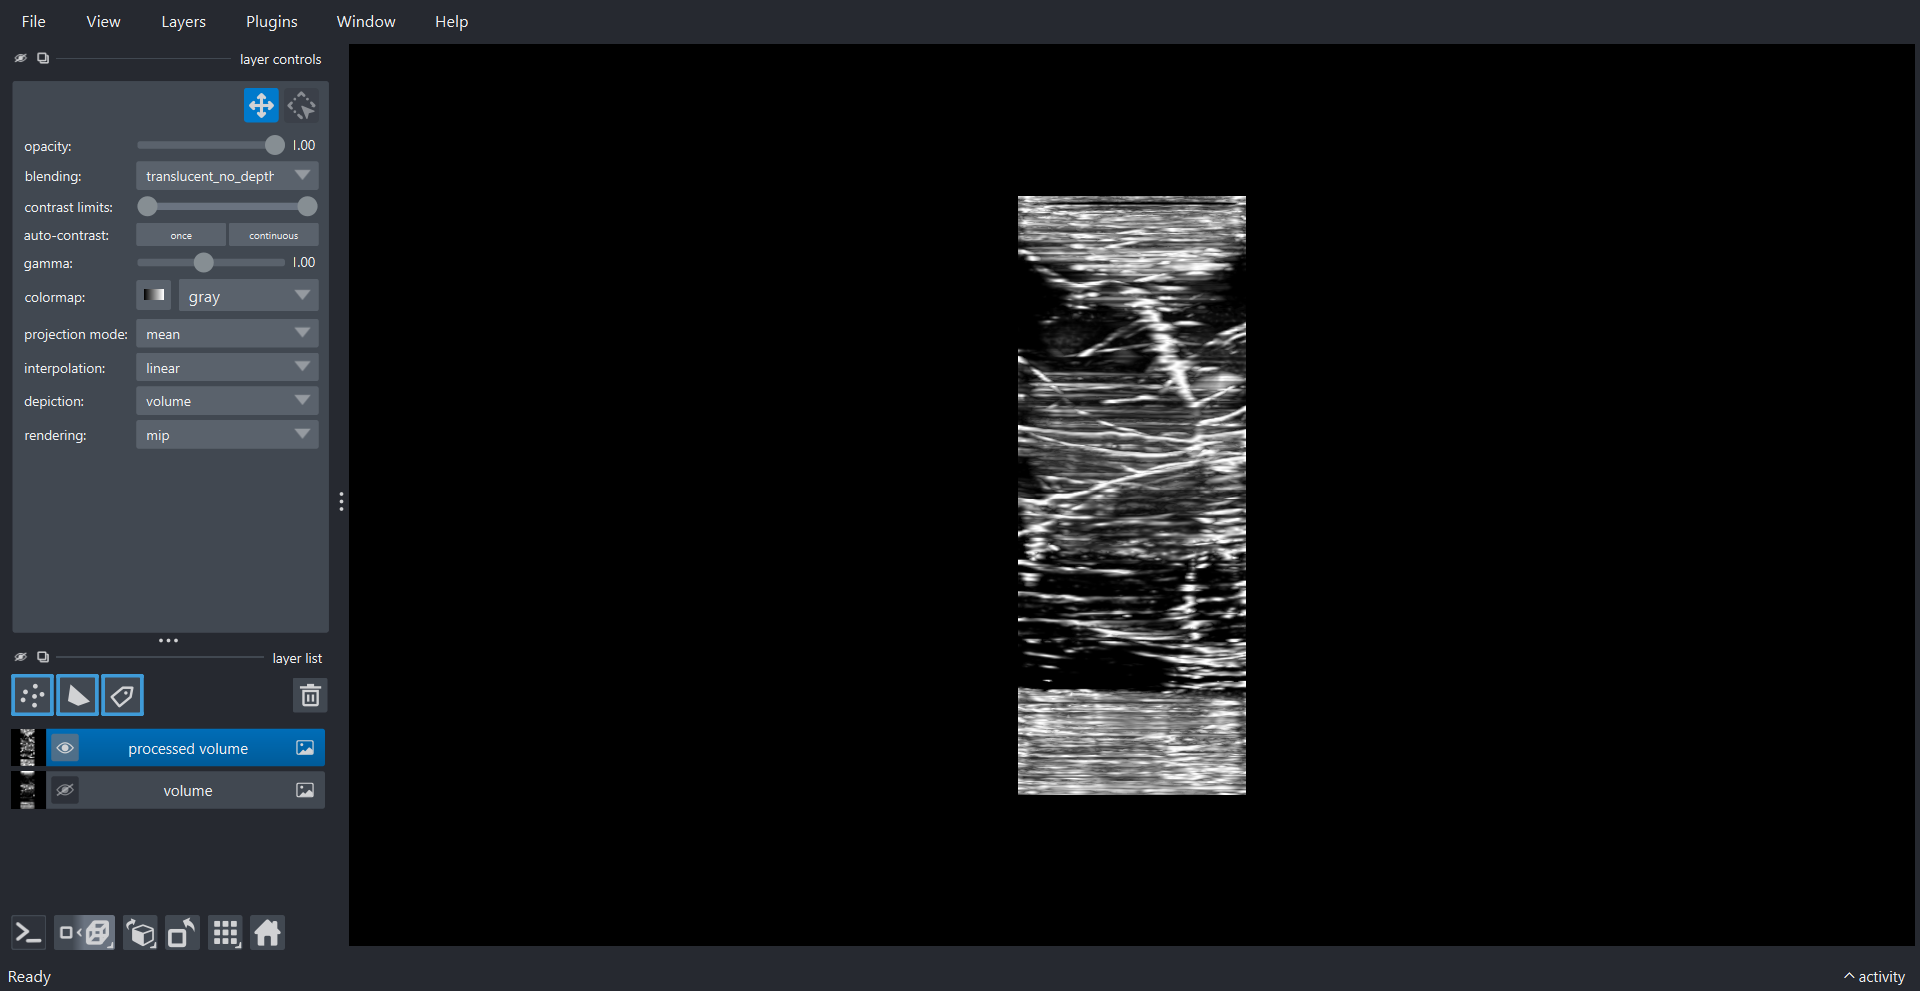

In [11]:
viewer_results = napari.Viewer(title='Meijering 2D Processing', ndisplay=3)
viewer_results.add_image(volume, name='volume', colormap='gray').visible = False
viewer_results.add_image(process_with_meijering(white_tophat_processed, sigmas=(1, 2, 3)), name='processed volume', colormap='gray')
nbscreenshot(viewer_results)

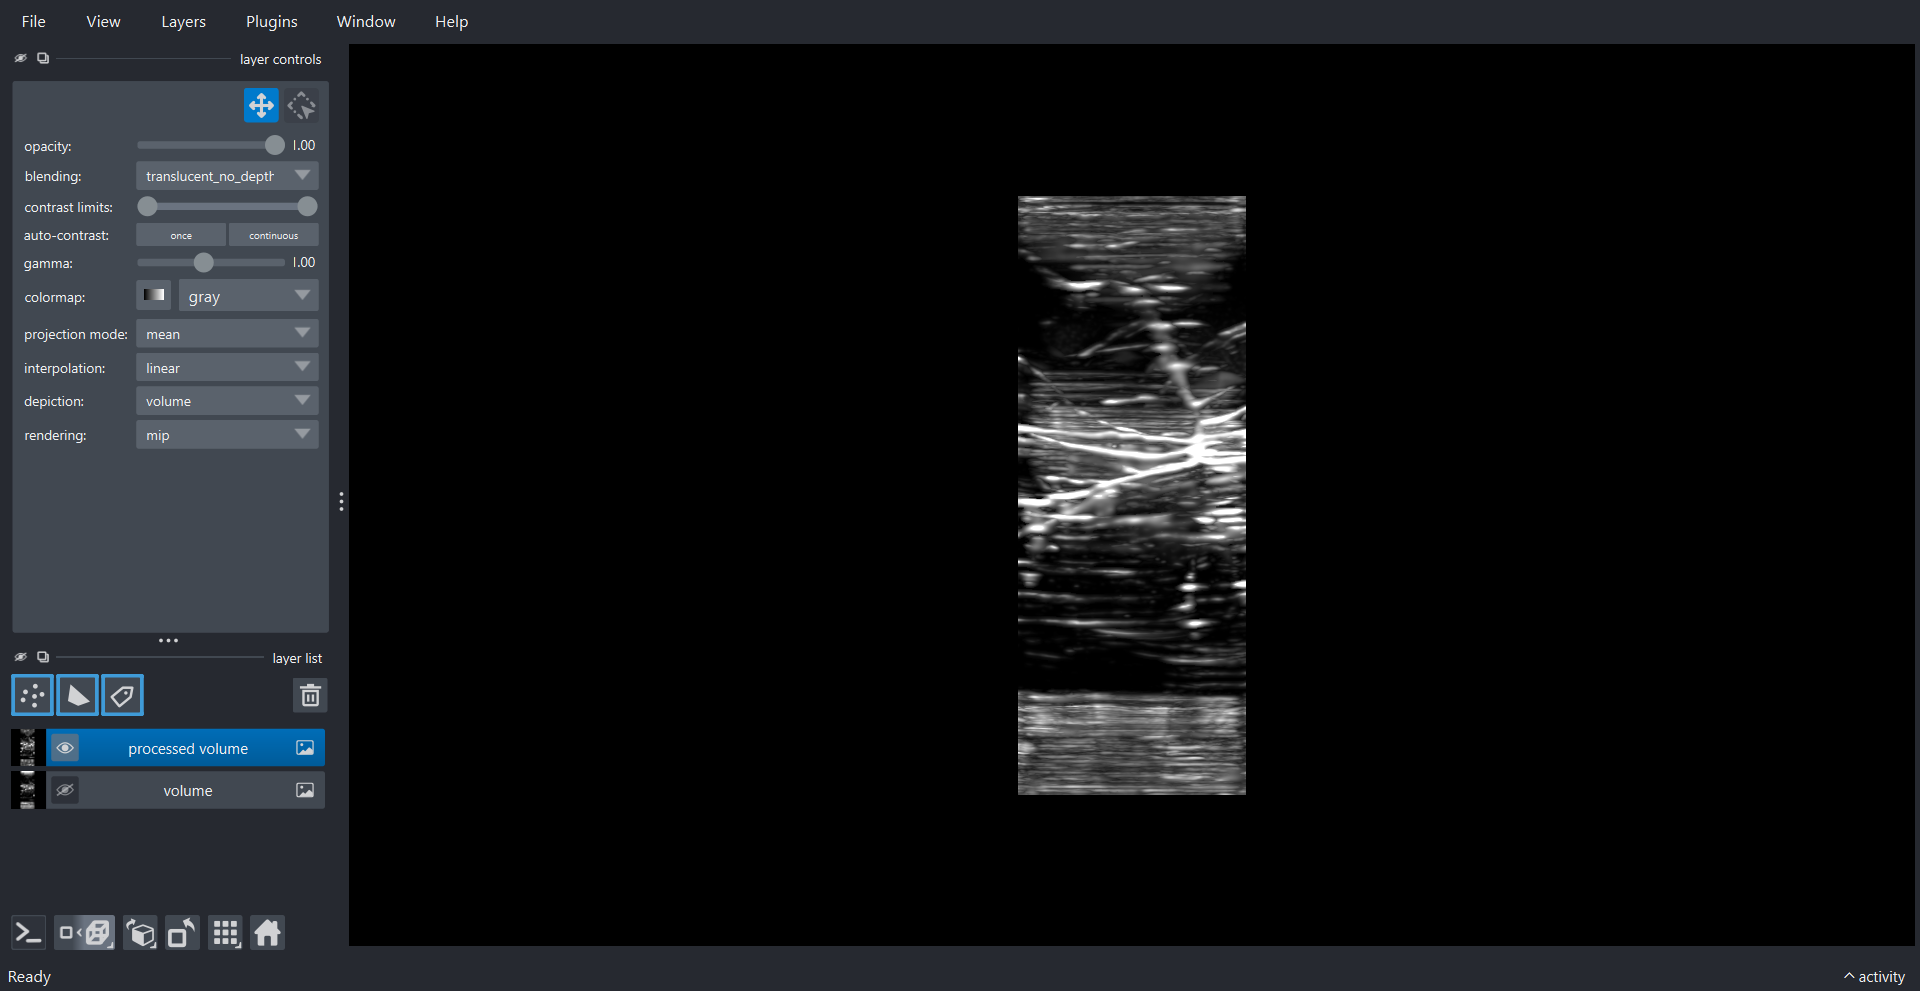

In [12]:
viewer_results = napari.Viewer(title='Meijering 3D Processing', ndisplay=3)
viewer_results.add_image(volume, name='volume', colormap='gray').visible = False
viewer_results.add_image(meijering(white_tophat_processed, black_ridges=False, sigmas=(1, 2, 3)), name='processed volume', colormap='gray')
nbscreenshot(viewer_results)

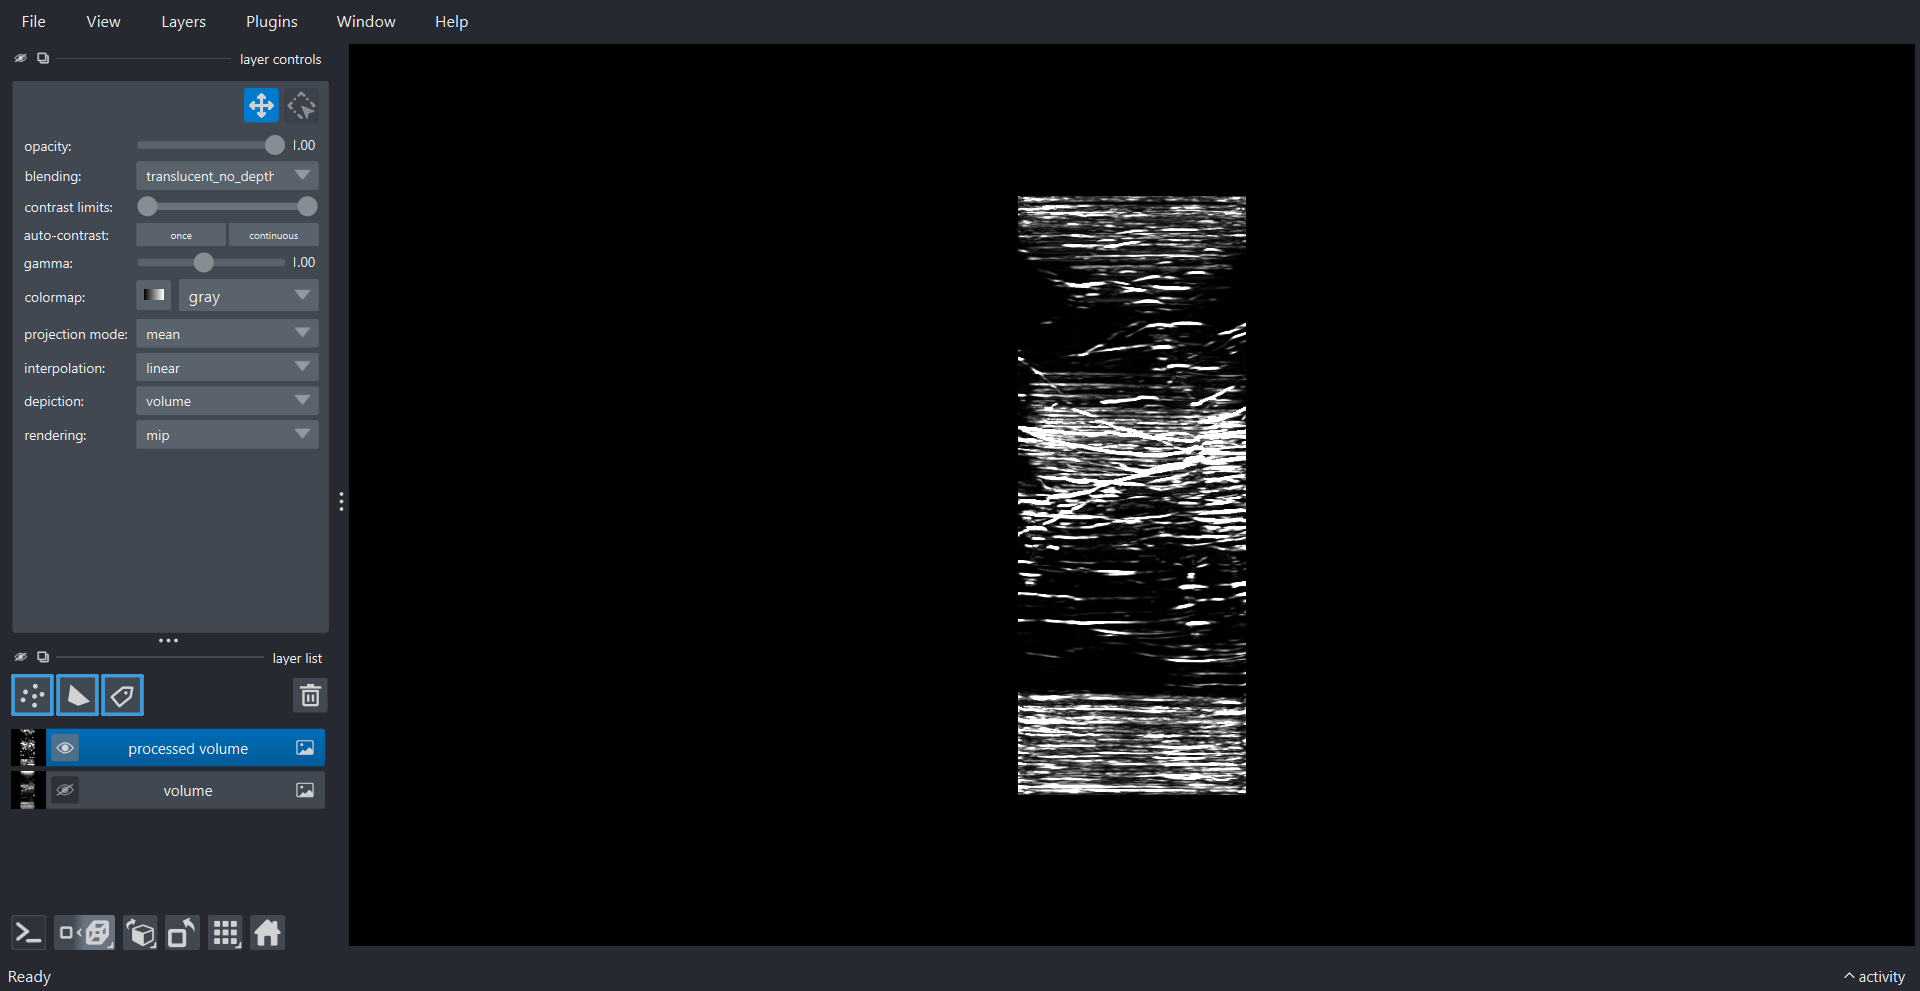

In [13]:
viewer_results = napari.Viewer(title='Frangi 3D Processing', ndisplay=3)
viewer_results.add_image(volume, name='volume', colormap='gray').visible = False
viewer_results.add_image(frangi(white_tophat_processed, black_ridges=False, sigmas=(1, 2, 3)), name='processed volume', colormap='gray')
nbscreenshot(viewer_results)

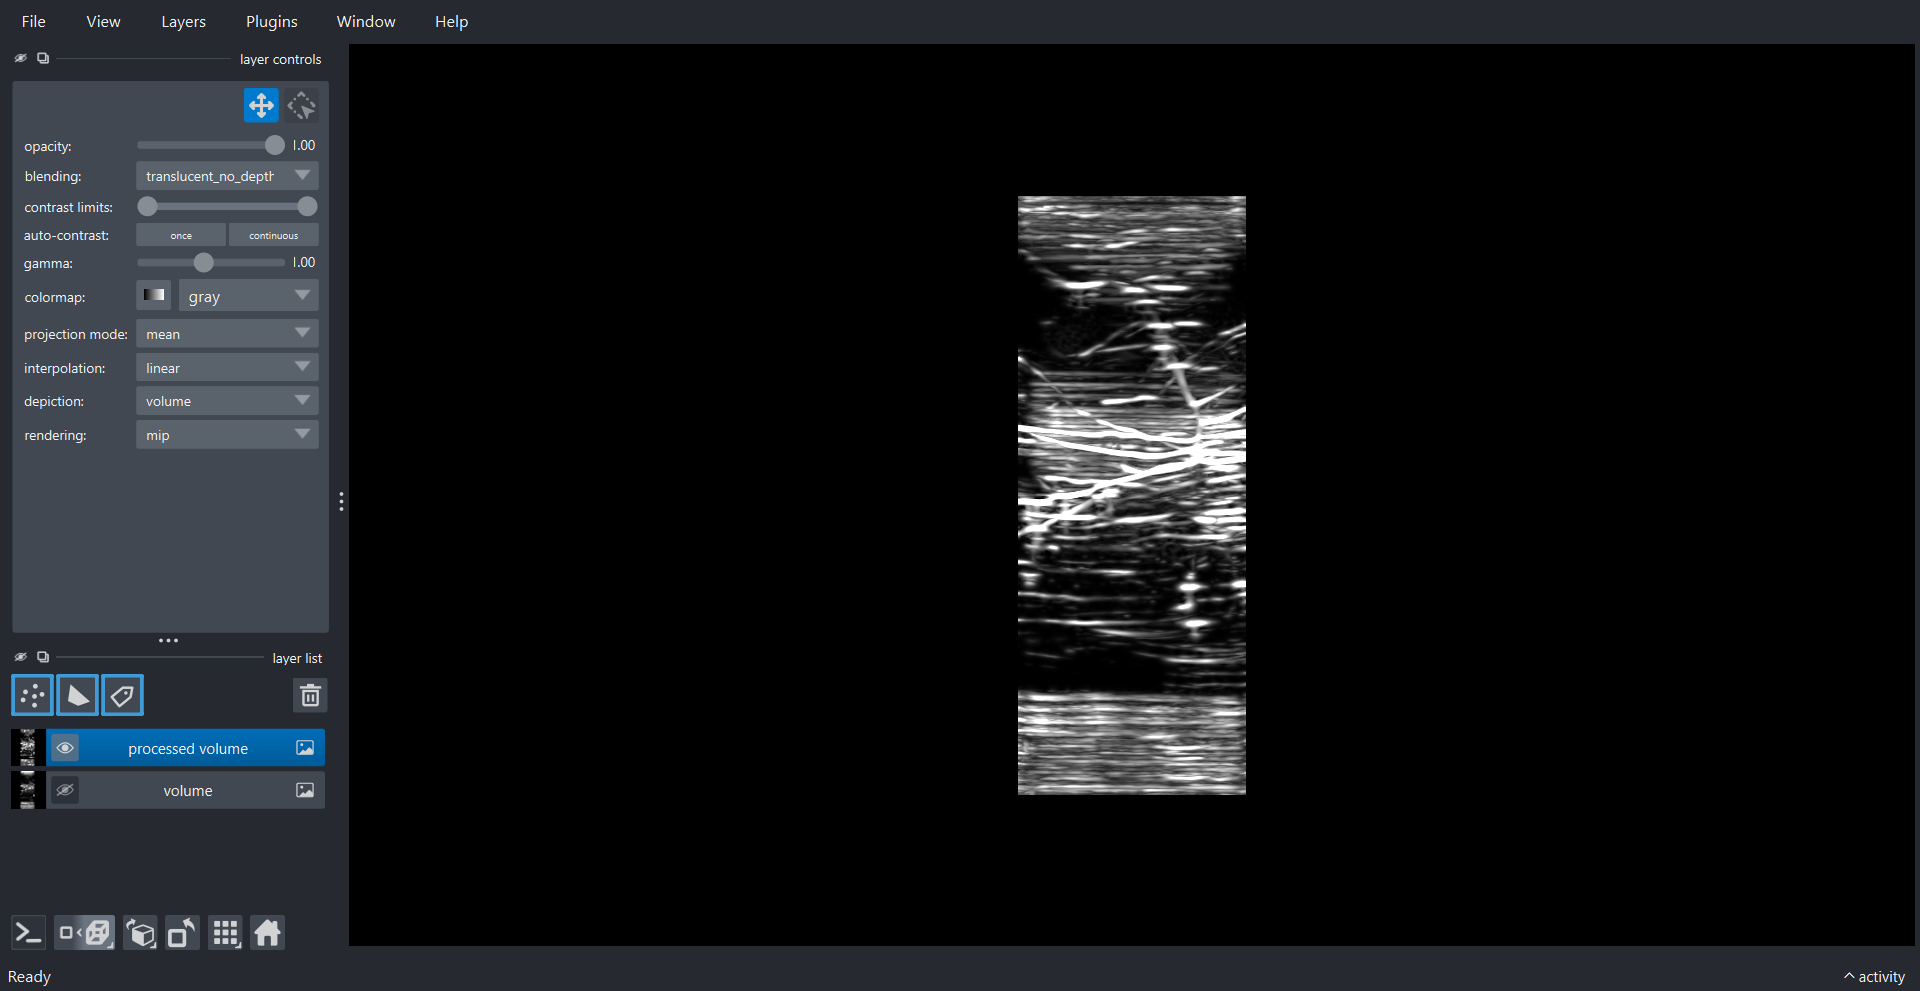

In [14]:
viewer_results = napari.Viewer(title='Sato 3D Processing', ndisplay=3)
viewer_results.add_image(volume, name='volume', colormap='gray').visible = False
viewer_results.add_image(sato(white_tophat_processed, black_ridges=False, sigmas=(1, 2, 3)), name='processed volume', colormap='gray')
nbscreenshot(viewer_results)